Install and Import Libraries:

Cosine Similarity Matrix:
[[ 1.   -0.01 -0.01  0.11  0.02  0.29]
 [-0.01  1.    0.08 -0.02  0.04  0.04]
 [-0.01  0.08  1.    0.03  0.19  0.14]
 [ 0.11 -0.02  0.03  1.    0.09  0.03]
 [ 0.02  0.04  0.19  0.09  1.    0.12]
 [ 0.29  0.04  0.14  0.03  0.12  1.  ]]


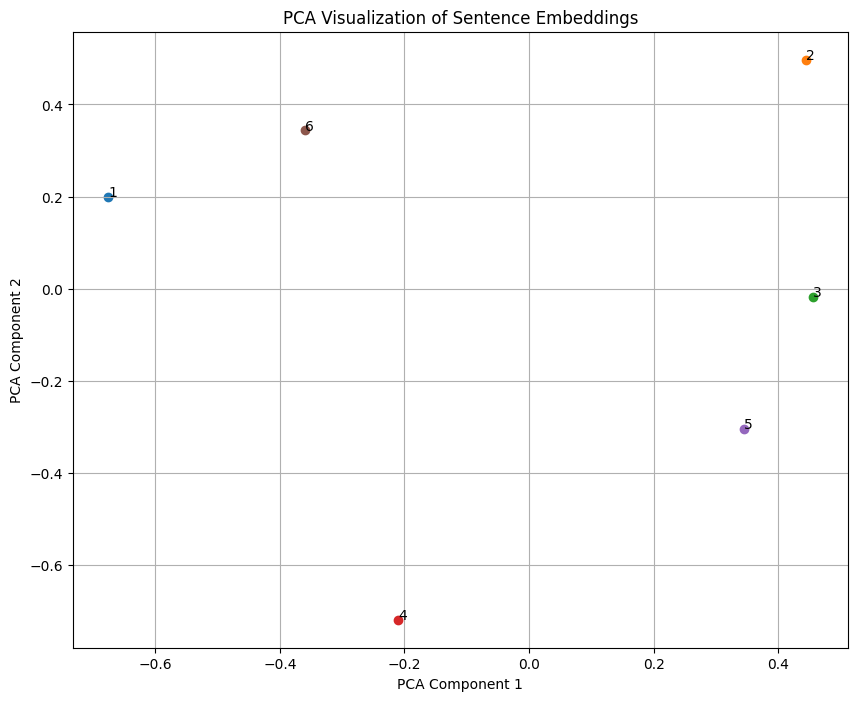


Query: 'What is Python used for?'
Top matches:
1. (Score: 0.586) Python is widely used in data analysis and machine learning.
2. (Score: -0.839) Cats are playful and love to sleep in warm places.
3. (Score: -0.905) I enjoy cooking traditional Indian dishes on weekends.

Query: 'Where can I see ancient Roman buildings?'
Top matches:
1. (Score: 0.139) Many tourists visit Rome to explore its ancient architecture.
2. (Score: -0.415) Paris is known for its art, fashion, and the Eiffel Tower.
3. (Score: -0.805) I enjoy cooking traditional Indian dishes on weekends.

Query: 'Tell me about football in Germany.'
Top matches:
1. (Score: 0.297) The German Bundesliga features some of the best football clubs.
2. (Score: -0.687) Paris is known for its art, fashion, and the Eiffel Tower.
3. (Score: -0.893) Cats are playful and love to sleep in warm places.

Testing different question formulations:

Query: 'what i cook on weekends'
Top matches:
1. (Score: 0.386) I enjoy cooking traditional Indian dis

In [4]:
# 1. Experiment with Sentence Embeddings
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import faiss
import json

# Load model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Sample texts
texts = [
   "Paris is known for its art, fashion, and the Eiffel Tower.",
    "Python is widely used in data analysis and machine learning.",
    "I enjoy cooking traditional Indian dishes on weekends.",
    "The German Bundesliga features some of the best football clubs.",
    "Cats are playful and love to sleep in warm places.",
    "Many tourists visit Rome to explore its ancient architecture."
    ]

# Generate embeddings
embeddings = model.encode(texts)

# Compute cosine similarity matrix
cos_sim = cosine_similarity(embeddings)
print("Cosine Similarity Matrix:")
print(np.round(cos_sim, 2))

# Visualize with PCA
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

plt.figure(figsize=(10, 8))
for i, txt in enumerate(texts):
    plt.scatter(embeddings_2d[i, 0], embeddings_2d[i, 1])
    plt.annotate(f"{i+1}", (embeddings_2d[i, 0], embeddings_2d[i, 1]))
plt.title("PCA Visualization of Sentence Embeddings")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid()
plt.show()

# 2. FAISS for Similarity Search
# Create FAISS index
dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)  # L2 distance index

# Normalize vectors to use cosine similarity
faiss.normalize_L2(embeddings)
index.add(embeddings)

# Query examples
queries = [
    "What is Python used for?",
    "Where can I see ancient Roman buildings?",
    "Tell me about football in Germany."
]

# Search function
def search(query, k=3):
    query_embedding = model.encode([query])
    faiss.normalize_L2(query_embedding)

    distances, indices = index.search(query_embedding, k)

    print(f"\nQuery: '{query}'")
    print("Top matches:")
    for i, (idx, dist) in enumerate(zip(indices[0], distances[0])):
        print(f"{i+1}. (Score: {1-dist:.3f}) {texts[idx]}")

# Perform searches
for query in queries:
    search(query)

# Different formulations of the same question
similar_questions = [
    "what i cook on weekends"
]

print("\nTesting different question formulations:")
for q in similar_questions:
    search(q, k=1)